In [1]:
%load_ext autoreload
%autoreload 2

**Author:** Salvador Navas  
**Date:** 2025-06-27

In [2]:
from pyhydra.data_sources.river_discharge import (
    download_usgs,
    get_usgs_site_info,
    search_usgs_sites,
)
import matplotlib.pyplot as plt
import pandas as pd
import os
RUN_DOWNLOADS = os.getenv('HYDRA_RUN_DOWNLOADS', '0') == '1'
df = pd.DataFrame()
print(f'Run downloads: {RUN_DOWNLOADS}')


Run downloads: False


# 🇺🇸 USGS NWIS — National Water Information System

## General Description

The **USGS NWIS** provides free, real-time and historical streamflow data for ~10,000 gauging
stations across the United States via a public REST API — **no registration required**.

| Property | Value |
|----------|-------|
| Coverage | United States and territories |
| Stations | ~10,000 active + ~100,000 historical |
| Temporal resolution | 15-min instantaneous + Daily values |
| Period | Varies by station; many from 1900s |
| Access | Public REST API, no credentials |

#### 🆚 USGS vs GloFAS — when to use which?

| Use case | USGS | GloFAS |
|----------|------|--------|
| US gauged catchments | ✅ Ground truth | ⚠️ Modelled, less accurate |
| Outside the US | ❌ Not available | ✅ Global |
| Real-time monitoring | ✅ 15-min updates | ❌ Daily only |
| Very long records (pre-1979) | ✅ Some from 1800s | ❌ ERA5 starts 1940 |

#### ⚠️ Data status: Provisional vs Approved

USGS data has two quality levels:
- **Provisional** (`P`): recently collected, not yet reviewed — may change
- **Approved** (`A`): reviewed and certified by a USGS hydrologist

> Always use **Approved** data for frequency analysis and publications.
> `download_usgs()` downloads daily values — check the `cd` (code) column in raw output
> for status flags if needed.

## 📦 Variables available

| Parameter code | Variable | Unit | Conversion |
|---------------|----------|------|-----------|
| `00060` | Discharge (default) | ft³/s | × 0.0283168 → m³/s |
| `00065` | Gage height | ft | × 0.3048 → m |
| `00010` | Water temperature | °C | — |
| `00300` | Dissolved oxygen | mg/L | — |

## 📌 API endpoint

```
https://waterservices.usgs.gov/nwis/dv/
```
Documentation: https://waterservices.usgs.gov/docs/daily-values/


---
## 1. 🔍 Search for stations in a region

`search_usgs_sites()` queries the NWIS REST API for all active streamflow gauges
within a bounding box `(west, south, east, north)` in decimal degrees.

```python
# Bounding box format: (west, south, east, north)
BBOX = (-107.0, 35.5, -105.5, 37.5)   # Northern New Mexico
stations = search_usgs_sites(bbox=BBOX)
```

The result includes station number, name, coordinates, and drainage area.
Use `drain_area_km2` to filter for catchments relevant to your study scale.


In [3]:
# Bounding box (west, south, east, north) in decimal degrees
BBOX = (-107.0, 35.5, -105.5, 37.5)   # Northern New Mexico

stations = search_usgs_sites(bbox=BBOX)
print(f"Stations found: {len(stations)}")
stations

Stations found: 160


---
## 2. ℹ️ Station metadata

`get_usgs_site_info()` returns key metadata for a specific site:
- `station_nm`: Full station name (river + location)
- `dec_lat_va` / `dec_long_va`: Coordinates
- `drain_area_va`: Drainage area in square miles
- `drain_area_km2`: Converted to km² by pyhydra

> The drainage area is essential for computing **unit hydrographs** and comparing
> specific discharge (Q/A, m³/s/km²) across basins of different sizes.


In [4]:
SITE = "08279500"   # Rio Grande at Embudo, NM  — update as needed

info = get_usgs_site_info(SITE)
print(info.T)

                                       0
site_no                         08279500
station_nm      RIO GRANDE AT EMBUDO, NM
dec_lat_va                     36.205556
dec_long_va                  -105.963972
drain_area_va                      10400
drain_area_km2                 26935.896


---
## 3. ⬇️ Download discharge data

`download_usgs()` fetches daily mean discharge from the NWIS REST API.
Set `units='metric'` to receive m³/s (converted from ft³/s automatically).

```python
# Download multiple sites at once
df_multi = download_usgs(
    site_no=['08279500', '08313000', '08317400'],
    start_date='2000-01-01',
    end_date='2020-12-31',
    units='metric',
)
```

> **Tip:** USGS daily values are midnight-to-midnight means in local time.
> If combining with precipitation data in UTC, verify time zone alignment.


In [5]:
if RUN_DOWNLOADS:
    # === CONFIGURATION ===
    SITE       = "08279500"
    START_DATE = "1980-01-01"
    END_DATE   = "2020-12-31"
    UNITS      = "metric"       # 'metric' → m³/s  |  'imperial' → ft³/s

    df = download_usgs(
        site_no=SITE,
        start_date=START_DATE,
        end_date=END_DATE,
        units=UNITS,
    )

    Q_col = f"Q_{SITE}"
    print(f"Downloaded : {len(df)} days")
    print(f"Missing    : {df[Q_col].isna().sum()} days  ({100*df[Q_col].isna().mean():.1f} %)")
    print(f"Mean Q     : {df[Q_col].mean():.2f} m³/s")
    print(f"Max  Q     : {df[Q_col].max():.1f} m³/s")
    df.head()
else:
    print('USGS download skipped in public mode. Set HYDRA_RUN_DOWNLOADS=1 to run it.')
    df = pd.DataFrame()


USGS download skipped in public mode. Set HYDRA_RUN_DOWNLOADS=1 to run it.


---
## 4. 📊 Visualisation

Three panels:
1. **Daily hydrograph** — peaks correspond to storm events; note the spring snowmelt peak
   for the Rio Grande (nival regime)
2. **Annual mean discharge** — long-term trend visible; dashed line = historical mean
3. **Seasonal regime** — mean discharge by month; confirms the nival pattern
   (March–April peak from Rocky Mountain snowmelt)


---
## 4. 📊 Visualisation

Traceback (most recent call last):
  File "/Users/salvadornavasfernandez/Desktop/Github/HYDRA/scripts/exec_nb.py", line 176, in run_notebook
    exec(compile(src_exec, f'<cell {cell_idx}>', 'exec'), ns)
  File "<cell 6>", line 4, in <module>
NameError: name 'Q_col' is not defined


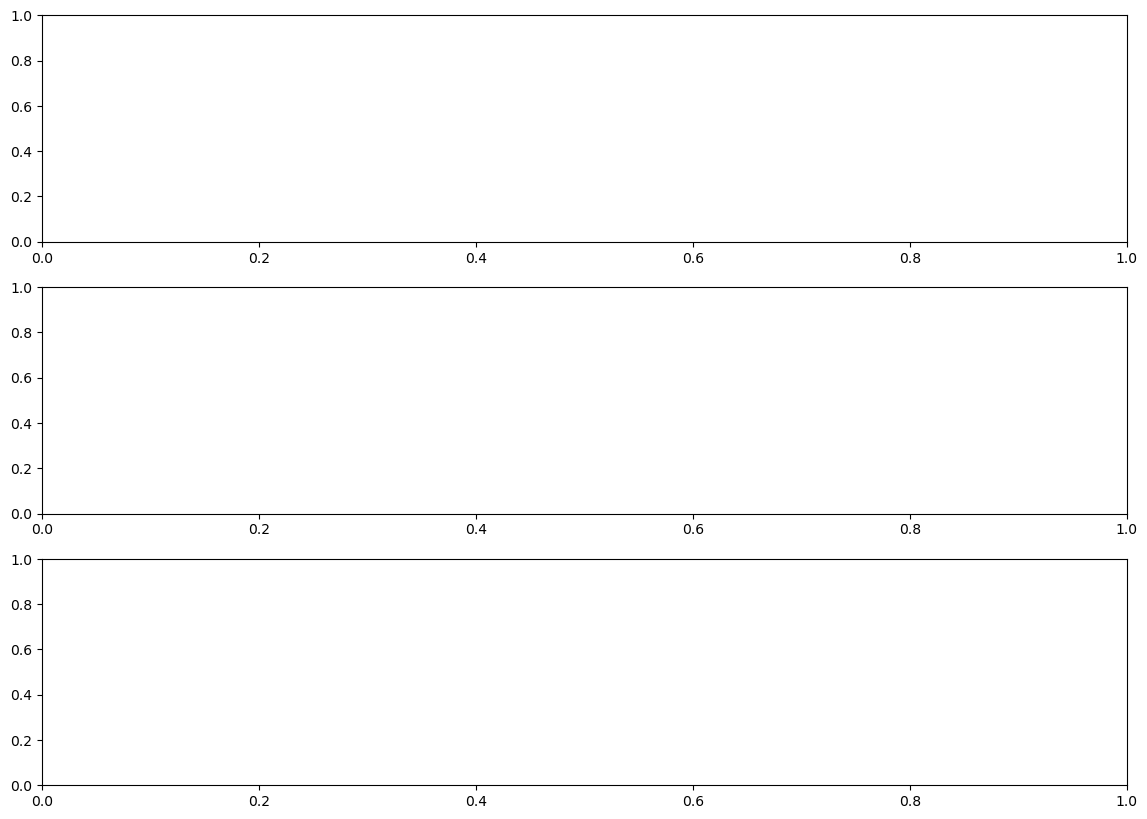

ExecutionError: NameError: name 'Q_col' is not defined

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Daily hydrograph
axes[0].plot(df.index, df[Q_col], lw=0.5, color="steelblue", alpha=0.8)
axes[0].set_ylabel("Daily discharge (m³/s)")
axes[0].set_title(f"USGS {SITE} — Rio Grande at Embudo, NM", fontsize=13)
axes[0].grid(alpha=0.3)

# Annual mean
annual = df[Q_col].resample("YE").mean()
axes[1].bar(annual.index.year, annual.values, color="steelblue", alpha=0.8)
axes[1].axhline(annual.mean(), color="red", lw=1.2, ls="--",
                label=f"Long-term mean: {annual.mean():.1f} m³/s")
axes[1].set_ylabel("Mean annual discharge (m³/s)")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Seasonal regime
monthly = df[Q_col].groupby(df.index.month).mean()
axes[2].bar(monthly.index, monthly.values, color="steelblue", alpha=0.85)
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                          "Jul","Aug","Sep","Oct","Nov","Dec"])
axes[2].set_ylabel("Mean discharge (m³/s)")
axes[2].set_xlabel("Month")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. 📉 Flow Duration Curve (FDC)

The **FDC** shows what fraction of time discharge exceeds a given value:

| Percentile | Symbol | Meaning |
|-----------|--------|--------|
| Q10 | High flow | Exceeded only 10% of time — near-flood conditions |
| Q50 | Median flow | Half the time above, half below — typical conditions |
| Q90 | Low flow | Exceeded 90% of time — near-drought / baseflow dominated |

The **slope of the FDC** indicates flow variability:
- **Steep slope**: flashy regime (high peaks, dry periods) — common in semi-arid basins
- **Flat slope**: regulated or groundwater-dominated flow — stable year-round

Q90 is widely used as the **ecological flow threshold** — the minimum flow
needed to maintain aquatic ecosystems.


In [7]:
# Flow duration curve
import numpy as np

Q_sorted  = df[Q_col].dropna().sort_values(ascending=False)
exceedance = 100 * np.arange(1, len(Q_sorted) + 1) / len(Q_sorted)

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(exceedance, Q_sorted.values, color="steelblue", lw=1.5)
for p, label in [(10, "Q10"), (50, "Q50"), (90, "Q90")]:
    idx = int(p / 100 * len(Q_sorted))
    qval = Q_sorted.iloc[idx]
    ax.axvline(p, color="gray", ls="--", lw=0.8)
    ax.annotate(f"{label}={qval:.1f}", xy=(p+0.5, qval), fontsize=9)
ax.set_xlabel("Exceedance probability (%)")
ax.set_ylabel("Discharge (m³/s)")
ax.set_title(f"Flow duration curve · USGS {SITE}", fontsize=12)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

Traceback (most recent call last):
  File "/Users/salvadornavasfernandez/Desktop/Github/HYDRA/scripts/exec_nb.py", line 176, in run_notebook
    exec(compile(src_exec, f'<cell {cell_idx}>', 'exec'), ns)
  File "<cell 7>", line 4, in <module>
NameError: name 'Q_col' is not defined


ExecutionError: NameError: name 'Q_col' is not defined

---
## ✅ Next steps

Downloaded USGS data is ready for:

- **Flood frequency analysis** → `extreme_value_analysis` notebook
  ```python
  annual_max = df[Q_col].resample('YE').max().dropna()
  ```

- **HEC-HMS calibration** — use daily observed Q as the target series
  → see `HEC_HMS` notebook

- **GloFAS validation** — compare modelled vs observed to compute NSE/KGE:
  ```python
  bias = df_glofas['discharge'].mean() / df[Q_col].mean()
  ```

- **Low-flow analysis** — Q90 as ecological flow or water supply threshold
